# Quickstart

Define a spherical galaxy, inspect its predicted line-of-sight dispersion,
generate mock velocities, and infer five parameters with **JAX and NumPyro NUTS**.
The [tutorials](tutorials/index.md)
explain the choices and add storage, restart and alternative backends.

Follow the [installation guide](installation.md) with the `numpyro_cpu` and
`plotting` extras. Run the following cells in order in a fresh Python process
or notebook kernel. Use **Restart Kernel and Run All Cells** to reproduce the complete example.

## 1. Define the model

The three components are a Plummer stellar tracer, a generalized NFW dark-matter
halo (`ZhaoModel` with `alpha=1`, `beta=3`) and constant spherical anisotropy.
We infer the inner density slope `gamma` along with the halo radius and density
scales, anisotropy and systemic velocity. The mock has `gamma=1` (standard NFW). JAX components receive physical parameters
on each call. Lengths are in **pc**, velocities in **km/s**, and mass densities
in **solar masses per pc³**. The normalized tracer contributes no gravitational
mass. Set the JAX environment before importing it.

In [1]:
import os
os.environ.setdefault("JEANSPY_JAX_PLATFORM", "cpu")
os.environ.setdefault("JEANSPY_JAX_ENABLE_X64", "true")

# The example uses no progress widgets; ignore only their optional-import warning.
import warnings
warnings.filterwarnings("ignore", message="IProgress not found.*")

# Import JeansPy before JAX so its runtime settings take effect.
from jeanspy.model_jax import (
    DSphModel, PlummerModel, ZhaoModel, ConstantAnisotropyModel,
)
from jeanspy.sampler_numpyro import JeansLikelihoodModel, ParameterSpec
import jax
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, init_to_value
import numpy as np
import matplotlib.pyplot as plt

model = DSphModel(submodels={
    "StellarModel": PlummerModel(),
    "DMModel": ZhaoModel(),
    "AnisotropyModel": ConstantAnisotropyModel(),
})
fixed = dict(re_pc=200., alpha=1., beta=3., r_t_pc=np.inf)
truth = dict(**fixed, rs_pc=500., rhos_Msunpc3=.1, gamma=1., beta_ani=0.)
options = dict(solver="kernel", n_u=128, n_kernel=32,
               dm_mass_method="numeric", dm_mass_n_steps=128)

`fixed` holds the tracer scale, `alpha=1`, `beta=3` and the untruncated halo
cutoff (`r_t_pc=np.inf`);
`truth` adds the parameters used to generate data. `options` chooses the
numerical resolution. The [backend tutorial](tutorials/backends.ipynb) explains
the JAX interface and compilation.

## 2. Plot the prediction and generate mock data

`sigmalos2` returns the intrinsic LOS **variance**, in (km/s)². Its square root
is the dispersion. A measured velocity additionally has measurement variance
`e_vlos_kms**2`. Here we generate 32 stars with Gaussian LOS velocities at
projected Plummer radii and a systemic velocity of zero.

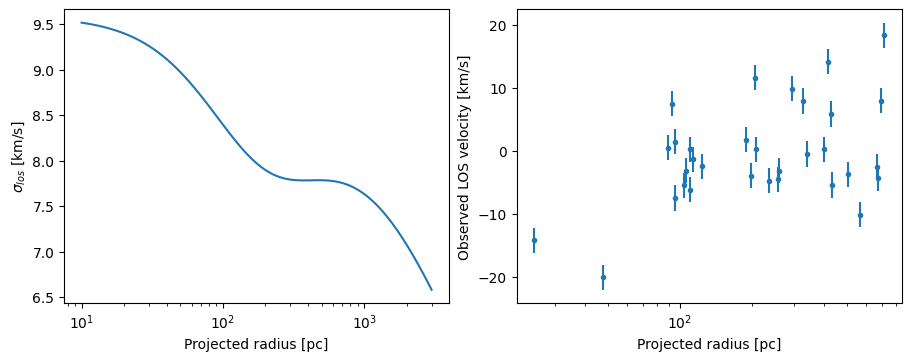

In [2]:
rng = np.random.default_rng(123)
u = rng.uniform(size=32)
R_pc = 200. * np.sqrt(u / (1. - u))  # Projected Plummer radii.
e_vlos_kms = np.full(32, 2.)
variance = np.asarray(model.sigmalos2(R_pc, params=truth, **options))
vlos_kms = rng.normal(0., np.sqrt(variance + e_vlos_kms**2))
data = dict(R_pc=R_pc, vlos_kms=vlos_kms, e_vlos_kms=e_vlos_kms)

R_grid = np.geomspace(10., 3000., 100)
sigma_kms = np.sqrt(model.sigmalos2(R_grid, params=truth, **options))
prediction, axes = plt.subplots(1, 2, figsize=(9, 3.5), layout="constrained")
axes[0].semilogx(R_grid, sigma_kms)
axes[0].set(xlabel="Projected radius [pc]", ylabel=r"$\sigma_{los}$ [km/s]")
axes[1].errorbar(R_pc, vlos_kms, yerr=e_vlos_kms, fmt=".")
axes[1].set(xscale="log", xlabel="Projected radius [pc]",
            ylabel="Observed LOS velocity [km/s]")
plt.show()

In an interactive notebook the figure is displayed immediately; the plots are saved with this notebook for reading without a kernel.
These mock velocities follow the Gaussian likelihood used below; they are
not samples from a full phase-space distribution function.

## 3. Run MCMC

Use `JeansLikelihoodModel` to combine the Jeans prediction and measurement
errors in a Gaussian velocity likelihood. `ParameterSpec` names each sampling
coordinate and its prior. `pow10` converts a sampled base-10 logarithm into
the positive physical scale passed to the model.

In [3]:
def physical_parameters(sampled):
    return {**fixed, **sampled}

likelihood = JeansLikelihoodModel(
    model,
    [ParameterSpec.pow10("log10_rs_pc", dist.Uniform(1.5, 4.), param_name="rs_pc"),
     ParameterSpec.pow10("log10_rhos_Msunpc3", dist.Uniform(-3., 1.),
                         param_name="rhos_Msunpc3"),
     ParameterSpec("gamma", dist.Uniform(0., 2.)),
     ParameterSpec("beta_ani", dist.Uniform(-1., .75)),
     ParameterSpec("vmem_kms", dist.Uniform(-50., 50.))],
    parameter_postprocess=physical_parameters,
    sigmalos2_kwargs=options,
)

The priors are uniform in the named coordinates: log halo radius, log halo
density, inner slope `gamma`, anisotropy and systemic velocity. The halo priors
span about 32–10,000 pc in scale radius, 0.001–10 solar masses per pc³ in
density scale, and `gamma=0` (a finite-density core) through `gamma=2` (a steep cusp).
They are illustrative choices
for this mock dataset. Run two independent chains sequentially on the CPU;
each has 200 warmup steps and 256 posterior draws. The first run also compiles
the JAX calculation and may take longer than subsequent evaluations.

In [4]:
kernel = NUTS(likelihood, target_accept_prob=.85,
              init_strategy=init_to_value(values={
                  "log10_rs_pc": np.log10(500.), "log10_rhos_Msunpc3": -1.,
                  "gamma": 1., "beta_ani": 0., "vmem_kms": 0.}))
mcmc = MCMC(kernel, num_warmup=200, num_samples=256,
            num_chains=2, chain_method="sequential", progress_bar=False)
mcmc.run(jax.random.PRNGKey(42), **data)

## 4. Inspect the result

Print the posterior summary, central 68% intervals and divergence count, then
plot the two chains separately. `get_samples(group_by_chain=True)` retains
the `(chain, draw)` axes; warmup is already excluded.

The 16%, 50% and 84% lines are marginal quantiles; the NumPyro summary
table above them uses its own default interval.


                          mean       std    median      5.0%     95.0%     n_eff     r_hat
            beta_ani      0.26      0.42      0.38     -0.38      0.74    240.94      1.01
               gamma      0.83      0.47      0.81      0.00      1.46    168.39      1.01
  log10_rhos_Msunpc3     -1.57      0.83     -1.66     -2.99     -0.44    157.65      1.01
         log10_rs_pc      3.21      0.53      3.26      2.49      3.99    182.52      1.00
            vmem_kms     -0.35      1.55     -0.38     -2.81      2.24    432.42      1.00

Number of divergences: 0
log10_rs_pc 16%, 50%, 84%: [2.64120599 3.25927649 3.77525493]
log10_rhos_Msunpc3 16%, 50%, 84%: [-2.39459069 -1.65517657 -0.71662544]
gamma 16%, 50%, 84%: [0.29710162 0.80858003 1.31702316]
beta_ani 16%, 50%, 84%: [-0.21152182  0.37810021  0.65304241]
vmem_kms 16%, 50%, 84%: [-1.77938956 -0.37797063  1.17765941]
Divergences: 0


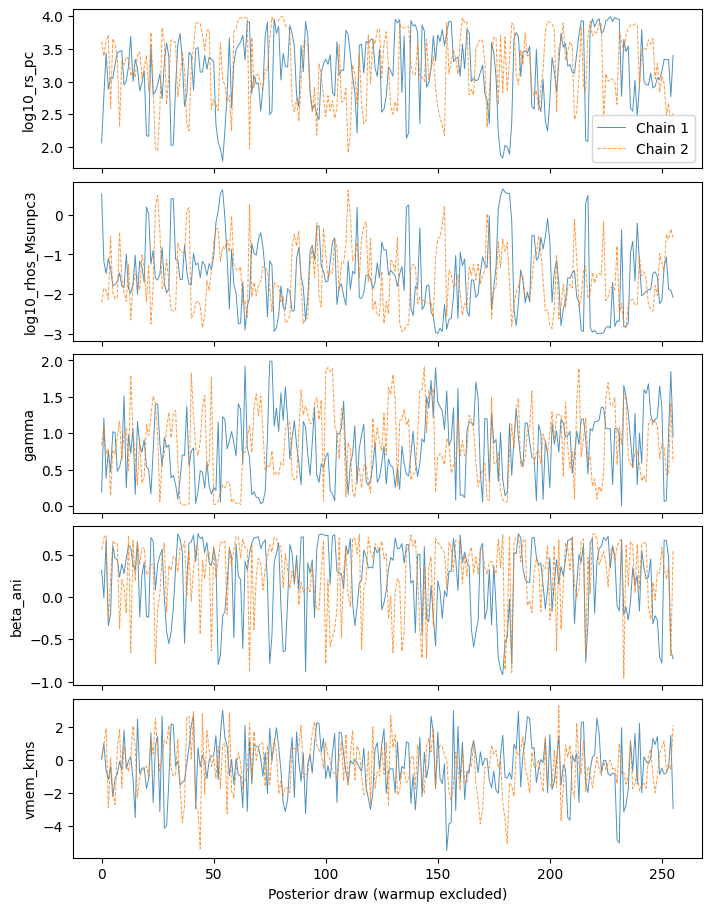

In [5]:
names = ["log10_rs_pc", "log10_rhos_Msunpc3", "gamma", "beta_ani", "vmem_kms"]
mcmc.print_summary(exclude_deterministic=True)
posterior = mcmc.get_samples(group_by_chain=True)  # Each value: (chain, draw).
for name in names:
    interval = np.quantile(np.asarray(posterior[name]), [.16, .5, .84])
    print(name, "16%, 50%, 84%:", interval)
print("Divergences:", int(mcmc.get_extra_fields()["diverging"].sum()))

traces, axes = plt.subplots(len(names), 1, figsize=(7, 9), sharex=True, layout="constrained")
for i, name in enumerate(names):
    for chain_index, values in enumerate(np.asarray(posterior[name])):
        axes[i].plot(values, alpha=.8, lw=.7,
                     ls=["-", "--"][chain_index], label=f"Chain {chain_index + 1}")
    axes[i].set_ylabel(name)
axes[0].legend()
axes[-1].set_xlabel("Posterior draw (warmup excluded)")
plt.show()

### Compare posterior profiles with the true and MAP models

First find a numerical **maximum a posteriori (MAP)** point. Here MAP refers
to density in the sampled coordinates
`(log10_rs_pc, log10_rhos_Msunpc3, gamma, beta_ani, vmem_kms)` with the priors above.
MAP depends on coordinates: maximizing density in linear radius/density is
a different problem. `log_density` evaluates the same likelihood and priors;
the unconstrained NUTS potential energy includes transformation Jacobians and
must not be used directly for this definition.

Bounded optimization starts from several posterior draws. The best successful
result is a numerical MAP candidate, not a proof of the global maximum. Its
reported objective should improve on the best saved draw. Inspect any prior
boundary reported below; a boundary mode can be strongly prior-dependent.


In [6]:
import jax.numpy as jnp
from numpyro.infer.util import log_density
from scipy.optimize import minimize

# Each row stays a joint posterior draw in the original sampling coordinates.
flat = np.column_stack([np.asarray(posterior[name]).reshape(-1) for name in names])
bounds = [(1.5, 4.), (-3., 1.), (0., 2.), (-1., .75), (-50., 50.)]

def log_posterior(theta):
    sampled = {name: theta[i] for i, name in enumerate(names)}
    return log_density(likelihood, (), data, sampled)[0]

value_and_grad = jax.jit(jax.value_and_grad(lambda theta: -log_posterior(theta)))

def objective(theta):
    value, gradient = value_and_grad(jnp.asarray(theta))
    return float(value), np.asarray(gradient, dtype=float)

# Start at the best saved draw and at draws spread across both chains.
logp_draws = np.asarray(jax.lax.map(log_posterior, jnp.asarray(flat)))
starts = np.unique(np.r_[np.argmax(logp_draws), np.linspace(0, len(flat)-1, 5, dtype=int)])
fits = [minimize(objective, flat[i], jac=True, bounds=bounds, method="L-BFGS-B",
                 options={"maxiter": 500, "ftol": 1e-10, "gtol": 1e-6}) for i in starts]
successful = [fit for fit in fits if fit.success and np.isfinite(fit.fun)]
if not successful:
    raise RuntimeError("MAP optimization did not converge; inspect the optimizer results.")
best_fit = min(successful, key=lambda fit: fit.fun)
map_theta = best_fit.x
assert -best_fit.fun >= logp_draws.max() - 1e-6
print("Converged MAP searches:", len(successful), "/", len(fits))
print("Numerical MAP:", dict(zip(names, np.round(map_theta, 4).tolist())))
print("MAP log posterior:", round(-best_fit.fun, 4))
print("Best saved-draw log posterior:", round(float(logp_draws.max()), 4))
at_bound = [name for name, value, (lo, hi) in zip(names, map_theta, bounds)
            if np.isclose(value, lo, atol=1e-5) or np.isclose(value, hi, atol=1e-5)]
print("MAP coordinates at a prior bound:", at_bound)


Converged MAP searches: 6 / 6
Numerical MAP: {'log10_rs_pc': 4.0, 'log10_rhos_Msunpc3': -2.1904, 'gamma': 0.6041, 'beta_ani': 0.75, 'vmem_kms': -0.2776}
MAP log posterior: -116.8054
Best saved-draw log posterior: -116.9309
MAP coordinates at a prior bound: ['log10_rs_pc', 'beta_ani']


Now propagate **every joint posterior draw** through the forward model.
The shading gives central 68% and 95% **pointwise credible intervals**;
the blue line is the pointwise median. These bands describe uncertainty in
the intrinsic dispersion and halo density, not the scatter of new observed
velocities and not a simultaneous interval for the entire curve. The orange
dashed MAP curve is one joint model, so it need not follow the median curve.
Black dotted curves show the mock's true model.


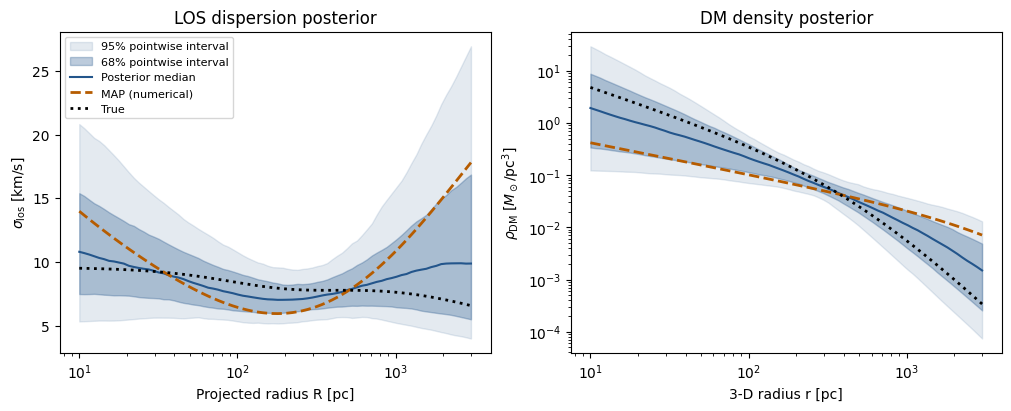

In [7]:
profile_grid = np.geomspace(10., 3000., 80)

def physical_from_theta(theta):
    log_rs, log_rho, g, beta, mean = theta
    return {**fixed, "rs_pc": 10.**log_rs, "rhos_Msunpc3": 10.**log_rho,
            "gamma": g, "beta_ani": beta, "vmem_kms": mean}

def profiles(theta):
    params = physical_from_theta(theta)
    sigma = jnp.sqrt(model.sigmalos2(profile_grid, params=params, **options))
    density = model["DMModel"].mass_density_3d(profile_grid, params=params)
    return jnp.stack([sigma, density])

# lax.map evaluates every joint draw without materializing a huge mass grid.
profile_draws = np.asarray(jax.lax.map(profiles, jnp.asarray(flat)))
assert np.all(np.isfinite(profile_draws) & (profile_draws > 0))
bands = np.quantile(profile_draws, [.025, .16, .5, .84, .975], axis=0)
true_theta = np.array([np.log10(truth["rs_pc"]), np.log10(truth["rhos_Msunpc3"]),
                       truth["gamma"], truth["beta_ani"], 0.])
true_profiles = np.asarray(profiles(true_theta))
map_profiles = np.asarray(profiles(map_theta))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
for i, ax in enumerate(axes):
    low95, low68, median, high68, high95 = bands[:, i]
    ax.fill_between(profile_grid, low95, high95, color="#23558b", alpha=.12,
                    label="95% pointwise interval")
    ax.fill_between(profile_grid, low68, high68, color="#23558b", alpha=.3,
                    label="68% pointwise interval")
    ax.plot(profile_grid, median, color="#23558b", label="Posterior median")
    ax.plot(profile_grid, map_profiles[i], color="#b65c00", ls="--", lw=2,
            label="MAP (numerical)")
    ax.plot(profile_grid, true_profiles[i], color="black", ls=":", lw=2, label="True")
    ax.set_xscale("log")
axes[0].set(xlabel="Projected radius R [pc]", ylabel=r"$\sigma_{\rm los}$ [km/s]",
            title="LOS dispersion posterior")
axes[1].set(xlabel="3-D radius r [pc]", ylabel=r"$\rho_{\rm DM}$ [$M_\odot$/pc$^3$]",
            yscale="log", title="DM density posterior")
axes[0].legend(fontsize=8)
plt.show()


Inspect mixing, effective sample size, R-hat and divergences before interpreting
the intervals. These short chains demonstrate the workflow; a run that finishes
does not establish convergence or interval calibration. The
[MCMC tutorial](tutorials/inference.ipynb) explains convergence diagnostics, NUTS divergences and corner contours.

Continue with [units and basic conventions](tutorials/units.ipynb), or go directly
to [saving and resuming results](tutorials/storage.ipynb). For individual signatures
and options, use the [API reference](api/index.md).